In [18]:
import pandas as pd
pd.set_option('display.max_rows', 50)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', 15)

import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from termcolor import colored

from utils import *
from utils_json import update_json
from data import datasetup

In [20]:
kwargs = {'data_path': 'data'
          , 'with_update' : False
          , 'in_place' : False
          , 'save_to_sql': False
    }

df = load_data(**kwargs)

df.shape

(1701, 9)

In [4]:
describe_analysis(df, datetime.now(), 'it_IT', True)

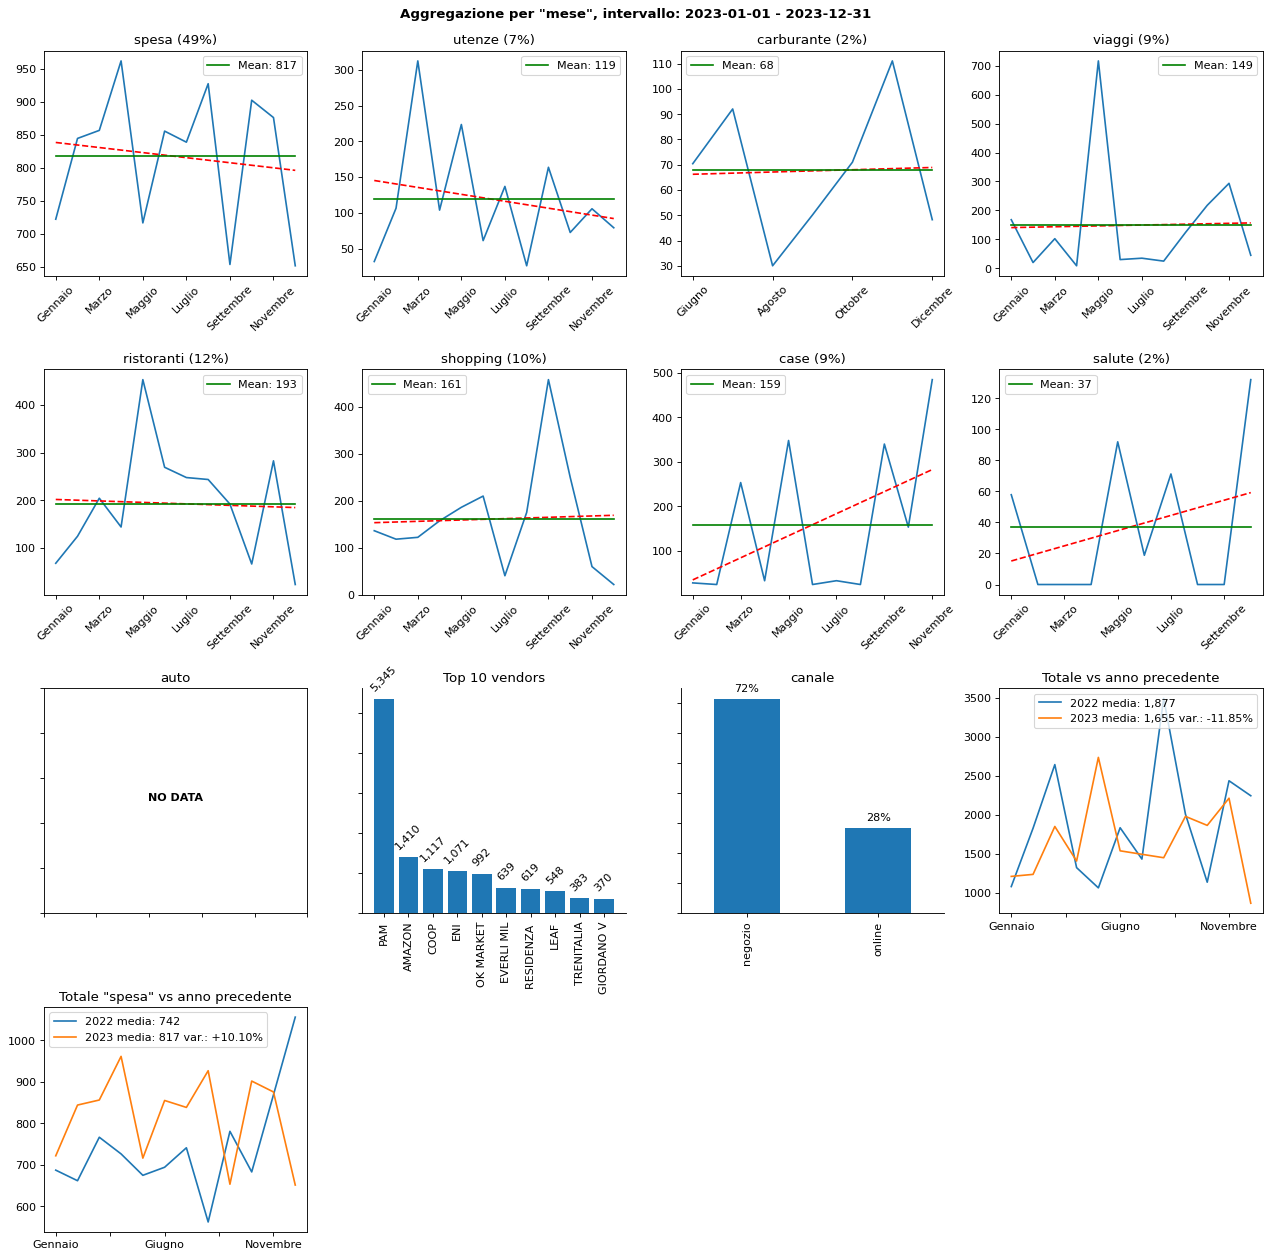

In [5]:
kw = {
    'df': df
    , 'start_date': '2023-01-01'
    , 'end_date': '2023-12-31'
    , '_sampling': ('M', 'mese')
    , '_nlargest': 10
    , '_classification': None # 'ristoranti'
    , '_locale': 'it_IT'
    , '_fig': {'figsize': (16,16), 'dpi':80}
}

plot_dashboard(**kw)

Skewness

Nuovi in classificazione

Nuovi in descrizione_standardizzata

AZ. AGRICOLA VIVAIO PASTO ALBISOLA SUPE
CAIAZZO M2 MILANO
FABBRICAZIONI IDRAULICHE ALBISOLA SUPE
FABBRO URGENZA MI
FARMACIA STELLA MARIS ALBISOLA SUPE
Fondazione Castiglioni
HOTEL CA' FORMENTA VENEZIA
JUSTEAT
KIKO
KINDLE
MANDOTTI MI
PANI&GRANI SAVONA
PAOLINO TRATTORIA VERCELLI
PAYPAL *33BC4 CINEMA 35314369001
PAYPAL *7D252 ENT 35314369001
PAYPAL *TICKETONESP 35314369001
PAYPAL *TICKETONESP 35314369001-1
POSTA
SAN GIOVANNI SAVONA SAVONA
STAZIONE ROYAL GARAGE GENOVA
STRANI SRL VENEZIA
TASKER ON TASKRABBIT MILTON KEYNES
VAPENSIERO SAS DI LUCA G GENOVA
VE.LA. S.P.A. VENEZIA

Categorical features

"classificazione" difference: set()

Base schema: ['carburante', 'case', 'ristoranti', 'salute', 'shopping', 'spesa', 'utenze', 'viaggi']

Eval schema: ['carburante', 'case', 'ristoranti', 'salute', 'shopping', 'spesa', 'utenze', 'viaggi']

Numeric features


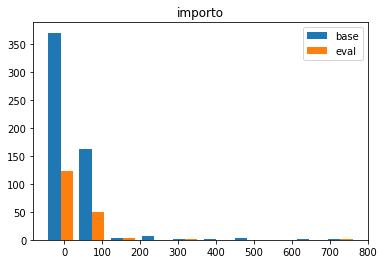


Type: float64


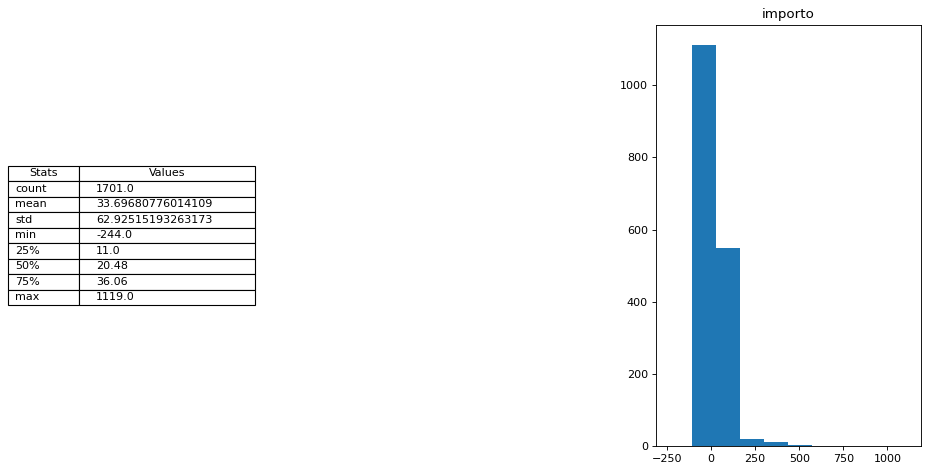


Type: object


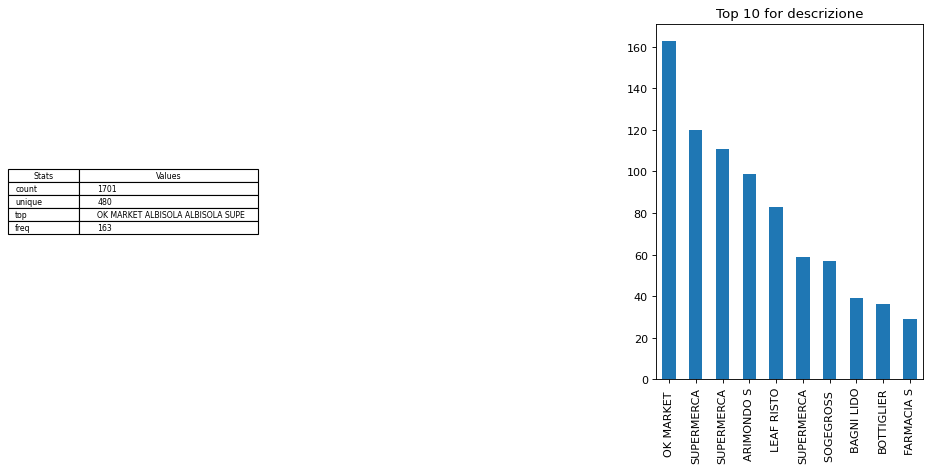

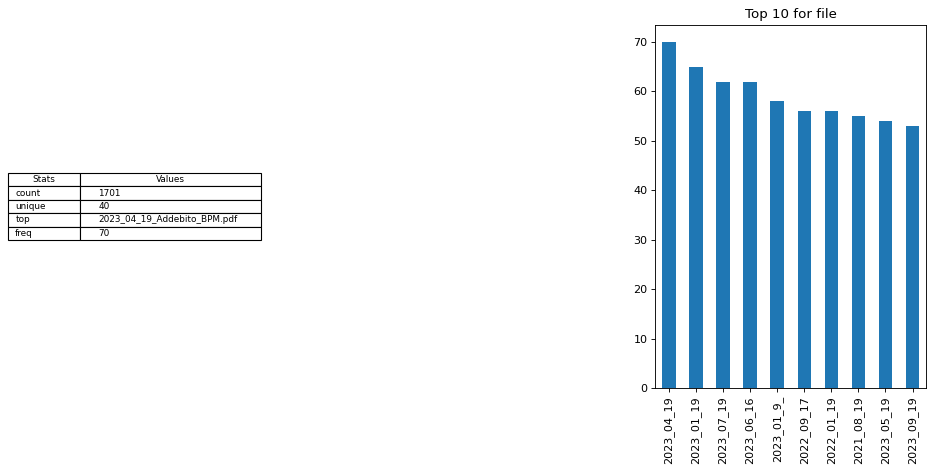

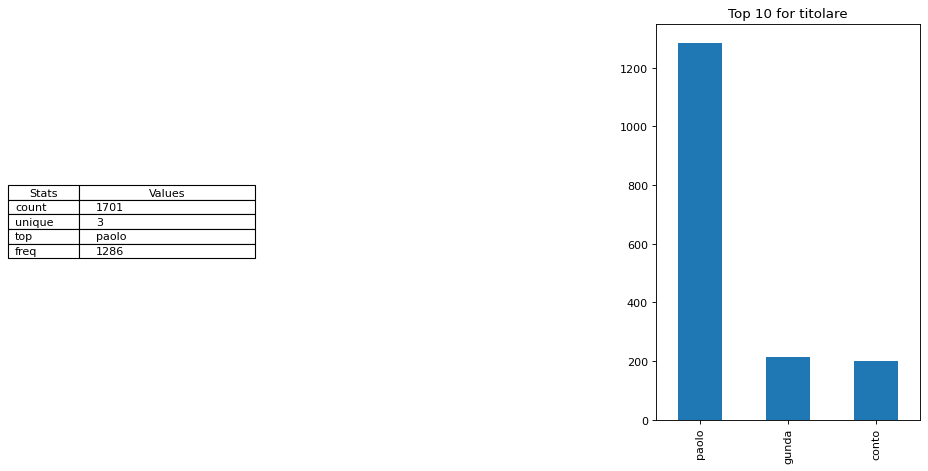

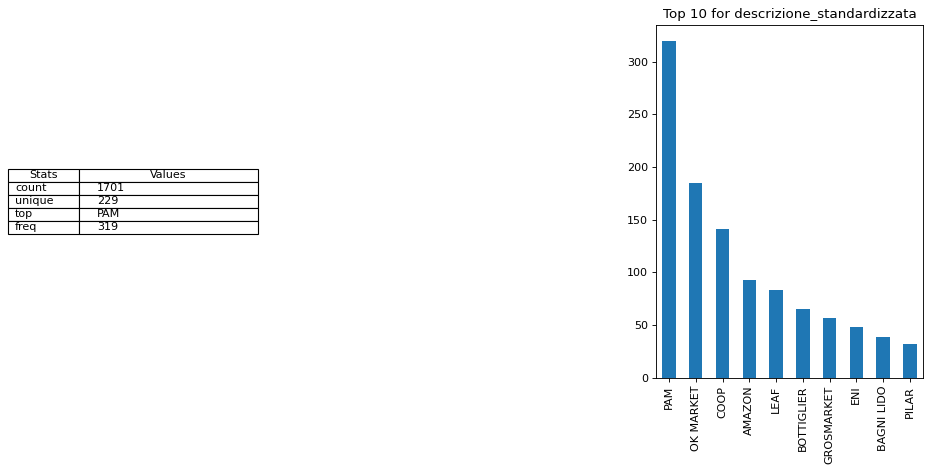

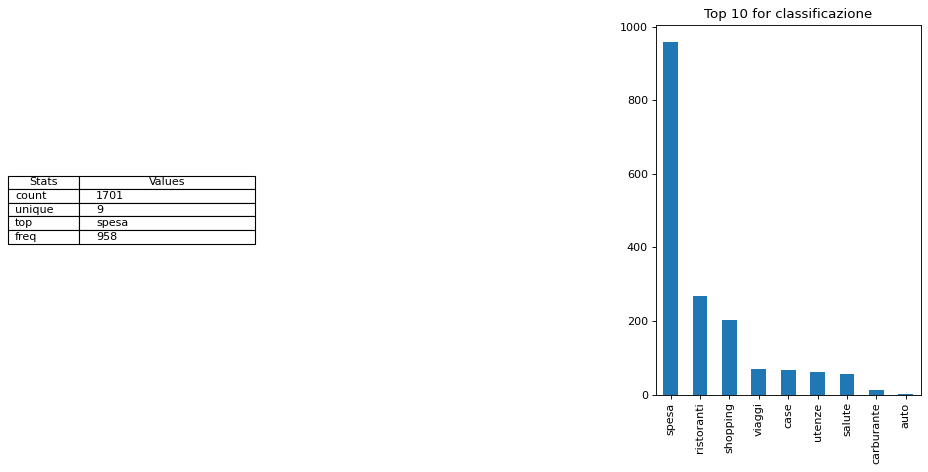

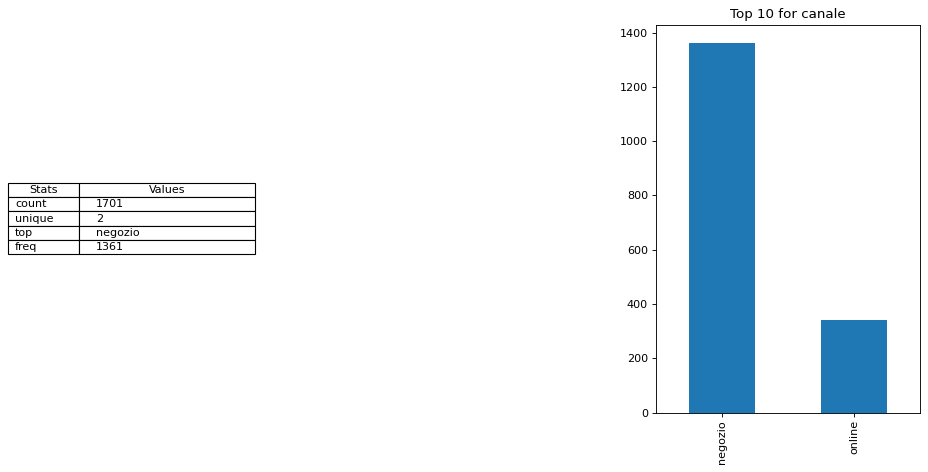

In [8]:
# Self made statistics

kwargs_skew = {'cat': ['classificazione']
           , 'num': ['importo']
           , 'filter_base': (df.data_acquisto >= '2023-01-01') & (df.data_acquisto <= '2023-9-30')
           , 'filter_eval': df.data_acquisto >= '2023-10-01'}

kwargs_slice = {'slice_col': 'classificazione', 'slice_index': 0}

data_validation(
    df = df # NO resampling
    , _include = ['object', 'number']
    , _exclude = None # 'object'
    , _skew = kwargs_skew
    , _slice = None # kwargs_slice
    , _schema = False
)

In [ ]:
# checking value of a classification by date range

print(
    '{:,.2f}€'.format(
    df.query('data_acquisto >= "2023-01-01" and data_acquisto <= "2023-11-30"')
    .loc[df.classificazione == 'spesa']
                                .set_index('data_acquisto')
                                ['importo'].sum()))